# 07 — Ablation Study

**input:** `data/movies.pkl`, `data/embeddings.npy`

**Question:** how much does each component contribute?

We compare three variants:

| Variant | Description |
|---|---|
| **Full (ours)** | Semantic clustering + Adaptive K |
| **Fixed K=3** | Semantic clustering + fixed K |
| **Fixed K=5** | Semantic clustering + fixed K |
| **No Retrieval** | starts from the full dataset instead of top-500 |

**Goal:** show that each design choice matters.

In [1]:
import numpy as np
import pandas as pd
import pickle, sys
from pathlib import Path
from sklearn.cluster import KMeans
from tqdm import tqdm
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('../')))
from src.query_templates import get_query_for_movie
from sentence_transformers import SentenceTransformer

DATA_DIR    = Path('../data')
RESULTS_DIR = Path('../results')

movies     = pd.read_pickle(DATA_DIR / 'movies.pkl')
embeddings = np.load(DATA_DIR / 'embeddings.npy')
sbert      = SentenceTransformer('all-MiniLM-L6-v2')

with open(DATA_DIR / 'results_ours.pkl', 'rb') as f:
    ours = pickle.load(f)
target_items = ours['target_items']

STOP_SIZE = 5
MAX_TURNS = 6
TOP_N     = 500

np.random.seed(42)
print(f'Targets: {len(target_items)}')
print('imports OK')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Targets: 200
imports OK


### Shared helper functions

In [2]:
import sys
sys.path.insert(0, '../')

from src.core import (
    entropy,
    expected_entropy,
    information_gain,
    adaptive_k,
    cluster_candidates,
    simulated_user,
    retrieve_candidates,
)

def rank_target(candidate_indices, target_idx, query_emb):
    if not candidate_indices:
        return len(embeddings) + 1
    scores = embeddings[candidate_indices] @ query_emb
    ranked = [candidate_indices[i] for i in np.argsort(scores)[::-1]]
    return ranked.index(target_idx) + 1 if target_idx in ranked else len(ranked) + 1

def recall_at_k(ranks, k):
    return np.mean([1 if r <= k else 0 for r in ranks])

def ndcg_at_k(ranks, k):
    scores = [1/np.log2(r+1) if r <= k else 0 for r in ranks]
    return np.mean(scores) / (1/np.log2(2))

print('functions OK')

functions OK


### Variant runner

In [3]:
def run_variant(target_idx, fixed_k=None, use_retrieval=True):
    """
    fixed_k=None  → adaptive K (full method)
    fixed_k=3     → fixed K = 3
    fixed_k=5     → fixed K = 5
    use_retrieval=False → start from the full dataset
    """
    genres = movies.iloc[target_idx]['genres']
    q_text = get_query_for_movie(genres)
    q_emb  = sbert.encode(q_text, normalize_embeddings=True)

    if use_retrieval:
        scores = embeddings @ q_emb
        C = np.argsort(scores)[::-1][:TOP_N].tolist()
    else:
        C = list(range(len(movies)))

    if target_idx not in C:
        C.append(target_idx)

    entropy_trace = [entropy(C)]
    ig_trace = []
    turn = 0

    while len(C) > STOP_SIZE and turn < MAX_TURNS:
        k = fixed_k if fixed_k else adaptive_k(len(C))
        partition, _ = cluster_candidates(C, embeddings, k)
        ig_trace.append(information_gain(C, partition))
        C = partition[simulated_user(partition, target_idx)]
        turn += 1
        entropy_trace.append(entropy(C))

    rank = rank_target(C, target_idx, q_emb)
    return {
        'turns':         turn,
        'final_size':    len(C),
        'rank':          rank,
        'entropy_trace': entropy_trace,
        'ig_trace':      ig_trace,
    }

print('variant runner ready')

variant runner ready


### Run all variants

In [4]:
variants = {
    'Full (Adaptive K)': dict(fixed_k=None,  use_retrieval=True),
    'Fixed K=3':         dict(fixed_k=3,     use_retrieval=True),
    'Fixed K=5':         dict(fixed_k=5,     use_retrieval=True),
    'No Retrieval':      dict(fixed_k=None,  use_retrieval=False),
}

all_results = {}
for name, kwargs in variants.items():
    results = []
    for t in tqdm(target_items, desc=name):
        r = run_variant(int(t), **kwargs)
        r['target_idx'] = int(t)
        results.append(r)
    all_results[name] = pd.DataFrame(results)
    print(f'{name}: avg_turns={all_results[name]["turns"].mean():.2f}, '
          f'final_size={all_results[name]["final_size"].mean():.2f}')

Full (Adaptive K): 100%|██████████| 200/200 [00:20<00:00,  9.89it/s]


Full (Adaptive K): avg_turns=4.36, final_size=3.46


Fixed K=3: 100%|██████████| 200/200 [00:19<00:00, 10.48it/s]


Fixed K=3: avg_turns=5.08, final_size=4.41


Fixed K=5: 100%|██████████| 200/200 [00:16<00:00, 11.92it/s]


Fixed K=5: avg_turns=3.58, final_size=2.38


No Retrieval: 100%|██████████| 200/200 [00:55<00:00,  3.61it/s]

No Retrieval: avg_turns=5.45, final_size=5.34


### Results

── Ablation Results (Recall@5 / NDCG@5) ──────────────
Variant                     Turns   FinalSz     R@5    NDCG@5
------------------------------------------------------------
Full (Adaptive K)            4.36      3.46   0.965     0.608
Fixed K=3                    5.08      4.41   0.880     0.532
Fixed K=5                    3.58      2.38   0.990     0.775
No Retrieval                 5.45      5.34   0.885     0.610


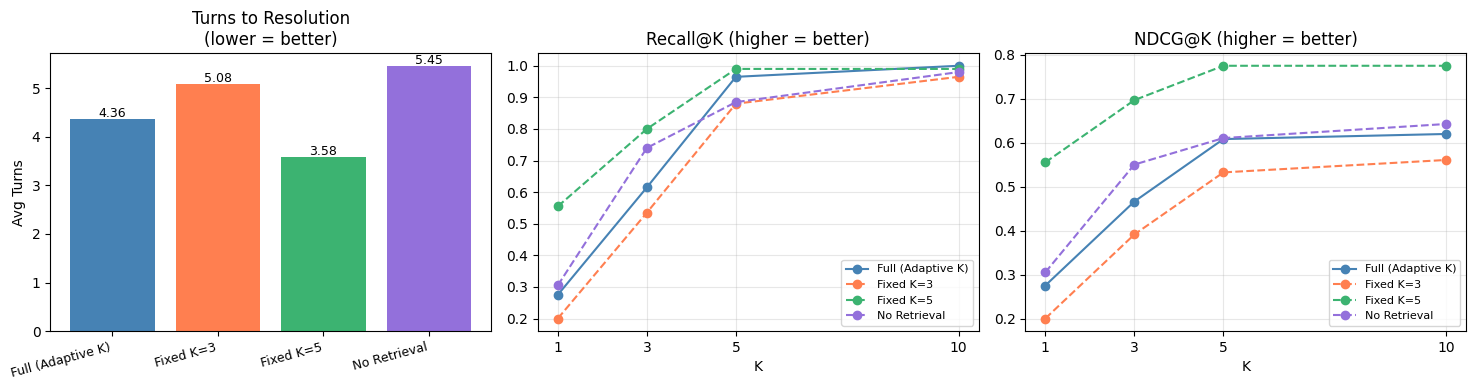

Saved: results/ablation.png

✅ notebook 07 complete


In [5]:
K_EVAL = 5

print(f'── Ablation Results (Recall@{K_EVAL} / NDCG@{K_EVAL}) ──────────────')
print(f'{"Variant":25s}  {"Turns":>6}  {"FinalSz":>8}  {"R@5":>6}  {"NDCG@5":>8}')
print('-' * 60)

for name, df in all_results.items():
    ranks = df['rank'].tolist()
    r5    = recall_at_k(ranks, K_EVAL)
    n5    = ndcg_at_k(ranks, K_EVAL)
    print(f'{name:25s}  {df["turns"].mean():>6.2f}  '
          f'{df["final_size"].mean():>8.2f}  {r5:>6.3f}  {n5:>8.3f}')

# ── Plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
names  = list(all_results.keys())

# Plot 1: Avg turns
turns_vals = [all_results[n]['turns'].mean() for n in names]
axes[0].bar(range(len(names)), turns_vals, color=colors)
axes[0].set_xticks(range(len(names)))
axes[0].set_xticklabels(names, rotation=15, ha='right', fontsize=9)
axes[0].set_ylabel('Avg Turns')
axes[0].set_title('Turns to Resolution\n(lower = better)')
for i, v in enumerate(turns_vals):
    axes[0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)

# Plot 2: Recall@K
ks = [1, 3, 5, 10]
for i, (name, color) in enumerate(zip(names, colors)):
    ranks = all_results[name]['rank'].tolist()
    vals  = [recall_at_k(ranks, k) for k in ks]
    ls    = '-' if i == 0 else '--'
    axes[1].plot(ks, vals, marker='o', color=color, label=name, linestyle=ls)
axes[1].set_xlabel('K')
axes[1].set_title('Recall@K (higher = better)')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
axes[1].set_xticks(ks)

# Plot 3: NDCG@K
for i, (name, color) in enumerate(zip(names, colors)):
    ranks = all_results[name]['rank'].tolist()
    vals  = [ndcg_at_k(ranks, k) for k in ks]
    ls    = '-' if i == 0 else '--'
    axes[2].plot(ks, vals, marker='o', color=color, label=name, linestyle=ls)
axes[2].set_xlabel('K')
axes[2].set_title('NDCG@K (higher = better)')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)
axes[2].set_xticks(ks)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'ablation.png', dpi=150)
plt.show()

print('Saved: results/ablation.png')
print()
print('✅ notebook 07 complete')